In [840]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [841]:
df = pd.read_csv('./data/dirty_data.csv')
df

,CustomerID,Age,Income,City,Signup_Date,Purchased
0,1001.0,unknown,27971.68,Houston,2022-01-01,No
1,1002.0,45yo,62015.76,Chicago,2022-01-02,No
2,1003.0,89,31728.49,Los Angeles,2022-01-03,yes
3,1004.0,78,47342.6,New York,2022-01-04,NaN
4,1005.0,38,NaN,Phoenix,2022-01-05,yes
...,...,...,...,...,...,...
315,NaN,71,74109.9,Phoenix,NaN,Yes
316,1290.0,NaN,41874.87,Los Angeles,2022-10-17,yes
317,NaN,NaN,$46460.11,Los Angeles,2022-07-31,Yes
318,1149.0,61,55861.19,Chicago,2022-05-29,No


check columns

In [842]:
df.columns

Index(['CustomerID', 'Age', 'Income', 'City', 'Signup_Date', 'Purchased'], dtype='object')

In [843]:
df = df.drop(columns=['CustomerID'])

In [844]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Age          284 non-null    object
 1   Income       285 non-null    object
 2   City         287 non-null    object
 3   Signup_Date  286 non-null    object
 4   Purchased    288 non-null    object
dtypes: object(5)
memory usage: 12.6+ KB


check_duplicates

In [845]:
df.duplicated().sum()

np.int64(7)

In [846]:
df.drop_duplicates()

,Age,Income,City,Signup_Date,Purchased
0,unknown,27971.68,Houston,2022-01-01,No
1,45yo,62015.76,Chicago,2022-01-02,No
2,89,31728.49,Los Angeles,2022-01-03,yes
3,78,47342.6,New York,2022-01-04,NaN
4,38,NaN,Phoenix,2022-01-05,yes
...,...,...,...,...,...
314,33,$50353.85,Phoenix,2022-07-02,Yes
315,71,74109.9,Phoenix,NaN,Yes
316,NaN,41874.87,Los Angeles,2022-10-17,yes
317,NaN,$46460.11,Los Angeles,2022-07-31,Yes


checking and handling nulls

In [847]:
df.isnull().sum()

Age            36
Income         35
City           33
Signup_Date    34
Purchased      32
dtype: int64

In [848]:
df.columns

Index(['Age', 'Income', 'City', 'Signup_Date', 'Purchased'], dtype='object')

In [849]:
categorical_columns = ['City', 'Purchased']
numerical_columns = ['Age', 'Income']
date_columns = ['Signup_Date']

In [850]:
from sklearn.impute import SimpleImputer

In [851]:
mode_imputer = SimpleImputer(strategy="most_frequent")
median_imputer = SimpleImputer(strategy='median')

SignUp Date

In [852]:
df[date_columns[0]] = pd.to_datetime(df[date_columns[0]], errors='coerce')

In [853]:
df[date_columns[0]].unique()

<DatetimeArray>
['2022-01-01 00:00:00', '2022-01-02 00:00:00', '2022-01-03 00:00:00',
 '2022-01-04 00:00:00', '2022-01-05 00:00:00', '2022-01-06 00:00:00',
 '2022-01-07 00:00:00', '2022-01-08 00:00:00',                 'NaT',
 '2022-01-10 00:00:00',
 ...
 '2022-10-17 00:00:00', '2022-10-18 00:00:00', '2022-10-19 00:00:00',
 '2022-10-20 00:00:00', '2022-10-21 00:00:00', '2022-10-22 00:00:00',
 '2022-10-23 00:00:00', '2022-10-24 00:00:00', '2022-10-25 00:00:00',
 '2022-10-27 00:00:00']
Length: 269, dtype: datetime64[ns]

In [854]:
mode_date = df['Signup_Date'].mode()[0]
df['Signup_Date'] = df['Signup_Date'].fillna(mode_date)

# imputers can't be used so use the mode instead, you can also just use a default value

In [855]:
df[date_columns[0]].unique()

<DatetimeArray>
['2022-01-01 00:00:00', '2022-01-02 00:00:00', '2022-01-03 00:00:00',
 '2022-01-04 00:00:00', '2022-01-05 00:00:00', '2022-01-06 00:00:00',
 '2022-01-07 00:00:00', '2022-01-08 00:00:00', '2022-01-10 00:00:00',
 '2022-01-11 00:00:00',
 ...
 '2022-10-17 00:00:00', '2022-10-18 00:00:00', '2022-10-19 00:00:00',
 '2022-10-20 00:00:00', '2022-10-21 00:00:00', '2022-10-22 00:00:00',
 '2022-10-23 00:00:00', '2022-10-24 00:00:00', '2022-10-25 00:00:00',
 '2022-10-27 00:00:00']
Length: 268, dtype: datetime64[ns]

City

In [856]:
df[categorical_columns[0]] = df[categorical_columns[0]].str.strip()
print(df[categorical_columns[0]].unique())

['Houston' 'Chicago' 'Los Angeles' 'New York' 'Phoenix' nan]


In [857]:
df[categorical_columns[0]] = mode_imputer.fit_transform(df[['City']]).ravel()
df[categorical_columns[0]] = df[categorical_columns[0]].astype('string')

In [858]:
print(df[categorical_columns[0]].unique())

<StringArray>
['Houston', 'Chicago', 'Los Angeles', 'New York', 'Phoenix']
Length: 5, dtype: string


Purchased

In [859]:
df[categorical_columns[1]] = df[categorical_columns[1]].str.strip().str.lower()
print(df[categorical_columns[1]].unique())


['no' 'yes' nan]


In [860]:
df[categorical_columns[1]] = mode_imputer.fit_transform(df[['Purchased']]).ravel()


In [861]:
print(df[categorical_columns[1]].unique())

['no' 'yes']


Age

In [862]:
df[numerical_columns[0]].unique()

array(['unknown', '45yo', '89', '78', '38', '250', '20', '39', nan, '19',
       '55', '81', '77', '50', '75', '66', '76', '59', '32', '79', '64',
       '68', '72', '24', '56', '35', '21', '31', '26', '70', '88', '61',
       '25', '52', '53', '67', '23', '71', '80', '51', '65', '57', '41',
       '58', '46', '62', '82', '18', '28', '22', '45', '40', '54', '44',
       '69', '60', '30', '49', '83', '74', '47', '87', '29', '73', '36',
       '85', '34', '86', '33', '37', '48', '42', '84', '63'], dtype=object)

In [863]:
df[numerical_columns[0]] = df[numerical_columns[0]].str.replace(r'\D','', regex=True)

In [864]:
df[numerical_columns[0]] = pd.to_numeric(df[numerical_columns[0]],errors='coerce')

In [865]:
df[numerical_columns[0]] = median_imputer.fit_transform(df[['Age']]).ravel()
df[numerical_columns[0]] = df[numerical_columns[0]].astype('int')

Income

In [866]:
df[numerical_columns[1]].unique()

array(['27971.68', '62015.76', '31728.49', '47342.6', nan, '57930.2',
       '-5000', '53083.98', '36998.02', '73020.71', '57247.51',
       '57113.61', '60316.29', '26795.31', '69495.88', '47335.83',
       '$73155.98', '52731.46', '49382.18', '43517.36', '$61334.71',
       '35381.29', '25141.01', '$42136.77', '67600.08', '81719.37',
       '44838.76', '31767.57', '49853.06', '57757.83', '63668.46',
       '87019.62', '58402.73', '79831.92', '48056.12', '56298.49',
       '46106.76', '44799.93', '51048.91', '50790.18', '45940.36',
       '$46761.21', '71451.94', '86696.68', '47523.9', '50134.07',
       '62869.14', '$102805.5', '56262.45', '69589.49', '78167.12',
       '60161.02', '68893.49', '64117.58', '70487.69', '39483.96',
       '58064.24', '62218.27', '72055.26', '61703.35', '37825.77',
       '$63869.74', '41753.82', '44509.33', '48722.37', '53328.72',
       '31844.12', '71753.4', '37667.26', '78551.66', '38125.72',
       '74228.81', '54573.68', '29253.63', '39355.58', '74

In [867]:
df[numerical_columns[1]] = df[numerical_columns[1]].str.replace(r'^\D', '' , regex='True')

In [868]:
df[numerical_columns[1]] =  pd.to_numeric(df[numerical_columns[1]],errors='coerce')

In [869]:
df[numerical_columns[1]] = median_imputer.fit_transform(df[['Income']]).ravel()

Check what nulls are left

In [870]:
df.isnull().sum()

Age            0
Income         0
City           0
Signup_Date    0
Purchased      0
dtype: int64

In [871]:
df.shape

(320, 5)

In [872]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Age          320 non-null    int64         
 1   Income       320 non-null    float64       
 2   City         320 non-null    string        
 3   Signup_Date  320 non-null    datetime64[ns]
 4   Purchased    320 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), string(1)
memory usage: 12.6+ KB


### Analysis

based on city

In [873]:
print('Income seems to balloon up based on the income of that City')
df.groupby(['City']).agg({'Income': 'sum', 'Purchased': 'count'})

Income seems to balloon up based on the income of that City


,Income,Purchased
City,,
Chicago,5488740.77,101
Houston,2999888.41,55
Los Angeles,2776782.00,51
New York,3202482.42,57
Phoenix,3005861.31,56


In [874]:
print("there seems to be no significant correlation between signup date and income")
df.groupby(['Signup_Date']).agg({'Income': 'sum', 'Purchased': 'count'})

there seems to be no significant correlation between signup date and income


,Income,Purchased
Signup_Date,,
2022-01-01,27971.68,1
2022-01-02,62015.76,1
2022-01-03,31728.49,1
2022-01-04,47342.60,1
2022-01-05,55356.27,1
...,...,...
2022-10-22,50528.42,1
2022-10-23,87592.63,1
2022-10-24,78442.20,1


based on age

In [875]:
print("there seems to be some correlation between age and purchased")
df.groupby(['Age']).agg({'Income': 'sum', 'Purchased': 'count'})

there seems to be some correlation between age and purchased


,Income,Purchased
Age,,
18,325569.65,6
19,545173.40,10
20,421504.97,8
21,298384.40,5
22,119756.53,2
...,...,...
86,126973.62,3
87,175261.59,3
88,187036.37,4


### Visualization

Skewness of Income:  -0.13974662138324018
It's mostly symmetric.


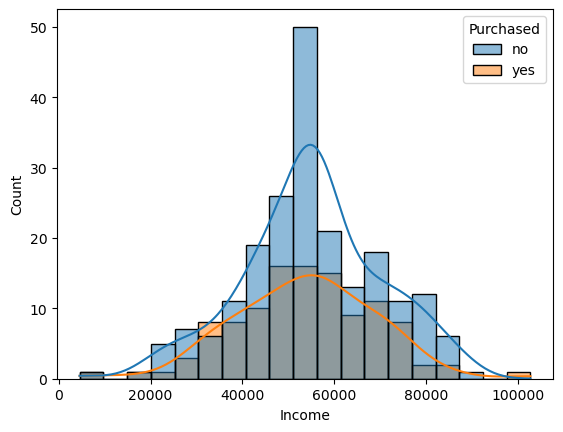

In [876]:
sns.histplot(data = df, x ='Income' , hue="Purchased", kde=True)
print("Skewness of Income: ", df['Income'].skew())
print("It's mostly symmetric.")

Skewness of Income:  1.9108999310510126
It's positively skewed which means Age might have outliers


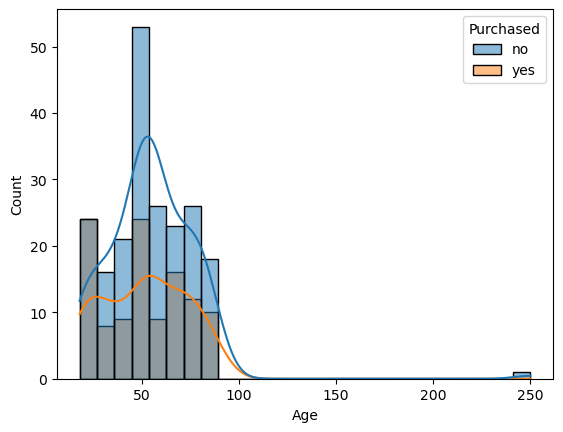

In [877]:
sns.histplot(data = df, x ='Age' , hue="Purchased", kde=True)
print("Skewness of Income: ", df['Age'].skew())
print("It's positively skewed which means Age might have outliers")

### Encoding Values

In [878]:
df

,Age,Income,City,Signup_Date,Purchased
0,53,27971.68,Houston,2022-01-01,no
1,45,62015.76,Chicago,2022-01-02,no
2,89,31728.49,Los Angeles,2022-01-03,yes
3,78,47342.60,New York,2022-01-04,no
4,38,55356.27,Phoenix,2022-01-05,yes
...,...,...,...,...,...
315,71,74109.90,Phoenix,2022-01-06,yes
316,53,41874.87,Los Angeles,2022-10-17,yes
317,53,46460.11,Los Angeles,2022-07-31,yes
318,61,55861.19,Chicago,2022-05-29,no


In [879]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
ohe = OneHotEncoder(sparse_output=False)

In [880]:
df['Purchased'] = le.fit_transform(df['Purchased'])
#no is 0, yes is 1

ohe_df = pd.DataFrame(ohe.fit_transform(df[['City']]), columns=ohe.get_feature_names_out(['City']))
df = pd.concat([df.drop(columns=['City']), ohe_df], axis=1)


In [881]:
df

,Age,Income,Signup_Date,Purchased,City_Chicago,City_Houston,City_Los Angeles,City_New York,City_Phoenix
0,53,27971.68,2022-01-01,0,0.0,1.0,0.0,0.0,0.0
1,45,62015.76,2022-01-02,0,1.0,0.0,0.0,0.0,0.0
2,89,31728.49,2022-01-03,1,0.0,0.0,1.0,0.0,0.0
3,78,47342.60,2022-01-04,0,0.0,0.0,0.0,1.0,0.0
4,38,55356.27,2022-01-05,1,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
315,71,74109.90,2022-01-06,1,0.0,0.0,0.0,0.0,1.0
316,53,41874.87,2022-10-17,1,0.0,0.0,1.0,0.0,0.0
317,53,46460.11,2022-07-31,1,0.0,0.0,1.0,0.0,0.0
318,61,55861.19,2022-05-29,0,1.0,0.0,0.0,0.0,0.0


### Removing Outliers and Erroneous data

<Axes: xlabel='Purchased', ylabel='Age'>

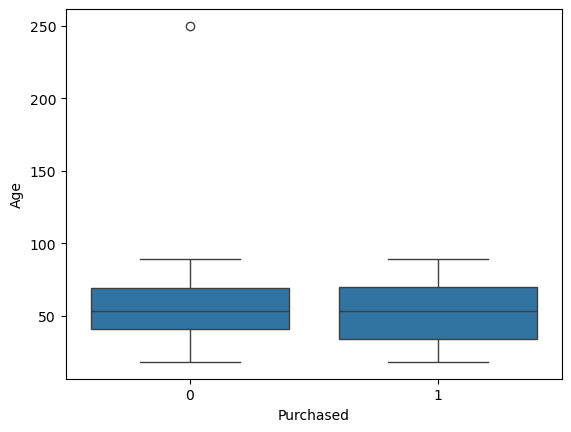

In [882]:
sns.boxplot(data = df, x='Purchased', y='Age')

In [883]:
def show_bounds_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("lower bound", lower_bound)
    print("upper bound", upper_bound)   

In [884]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return clean_data


In [885]:
show_bounds_iqr(df,'Age' )

lower bound -9.125
upper bound 115.875


In [886]:
df = remove_outliers_iqr(df, 'Age')

<Axes: xlabel='Purchased', ylabel='Age'>

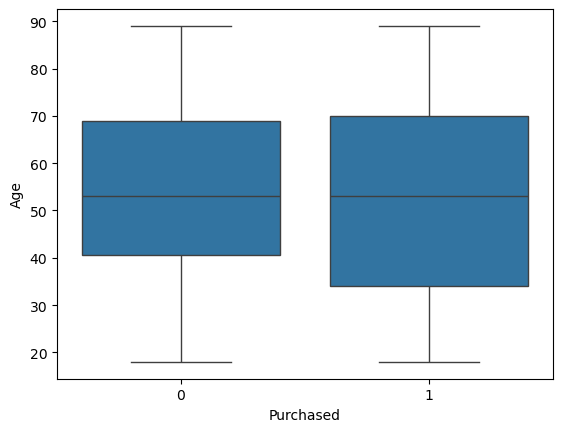

In [887]:
sns.boxplot(data = df, x='Purchased', y='Age')

<Axes: xlabel='Purchased', ylabel='Income'>

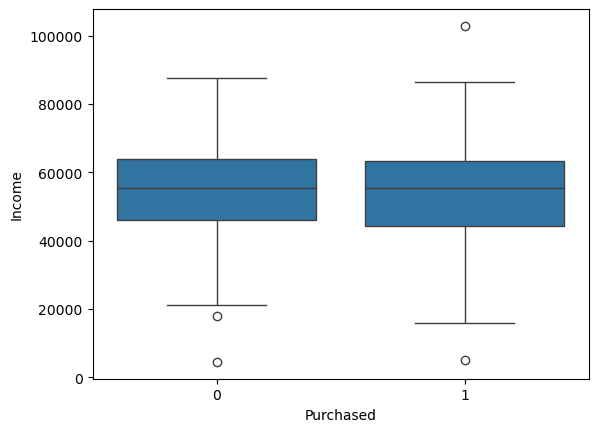

In [888]:
sns.boxplot(data = df, x='Purchased', y='Income')

In [889]:
show_bounds_iqr(df,'Income' )

lower bound 18352.199999999993
upper bound 91019.24


In [890]:
df = remove_outliers_iqr(df, 'Income')

<Axes: xlabel='Purchased', ylabel='Income'>

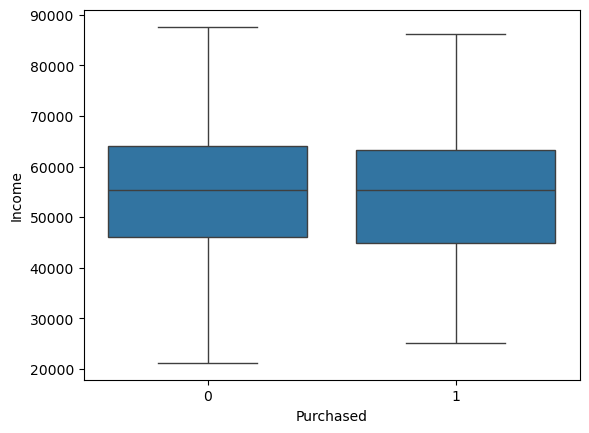

In [891]:
sns.boxplot(data = df, x='Purchased', y='Income')

### Feature Engineering

In [892]:
teenager = 13
adult = 21
senior = 60

df['Age Group'] = df['Age'].apply(lambda x: 0 if x < teenager else 1 if x >= teenager and x < adult else 2 if x >= adult and x < senior else 3)
df['Income Group'] = df['Income'].apply(lambda x: 0 if x < 45000 else 1 if x >= 45000 and x < 65000 else 2 )

In [893]:
df['Signup_Year'] = df['Signup_Date'].dt.year
df['Signup_Month'] = df['Signup_Date'].dt.month
df['Signup_Day'] = df['Signup_Date'].dt.day


In [894]:
df_feat = df.copy().drop(columns=['Signup_Date'])
df_feat

,Age,Income,Purchased,City_Chicago,City_Houston,City_Los Angeles,City_New York,City_Phoenix,Age Group,Income Group,Signup_Year,Signup_Month,Signup_Day
0,53,27971.68,0,0.0,1.0,0.0,0.0,0.0,2,0,2022,1,1
1,45,62015.76,0,1.0,0.0,0.0,0.0,0.0,2,1,2022,1,2
2,89,31728.49,1,0.0,0.0,1.0,0.0,0.0,3,0,2022,1,3
3,78,47342.60,0,0.0,0.0,0.0,1.0,0.0,3,1,2022,1,4
4,38,55356.27,1,0.0,0.0,0.0,0.0,1.0,2,1,2022,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,71,74109.90,1,0.0,0.0,0.0,0.0,1.0,3,2,2022,1,6
316,53,41874.87,1,0.0,0.0,1.0,0.0,0.0,2,0,2022,10,17
317,53,46460.11,1,0.0,0.0,1.0,0.0,0.0,2,1,2022,7,31
318,61,55861.19,0,1.0,0.0,0.0,0.0,0.0,3,1,2022,5,29


### Splitting and Sampling

In [895]:
X = df_feat.drop(columns=['Purchased'])
y = df_feat['Purchased']

<Axes: xlabel='Purchased', ylabel='count'>

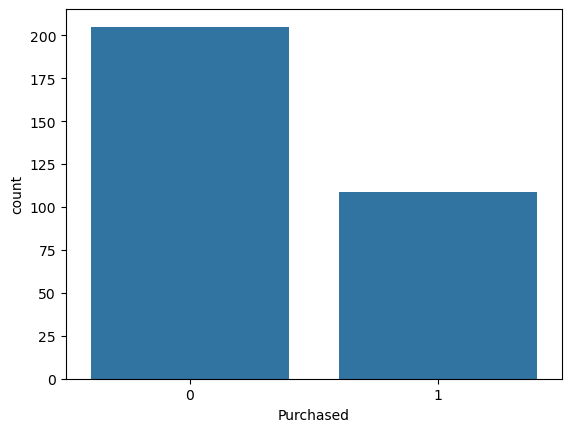

In [896]:
sns.countplot(data = df_feat, x = 'Purchased')

Splitting

In [897]:
from sklearn.model_selection import train_test_split

In [898]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Sampling

In [899]:
from imblearn.over_sampling import  SMOTE
smote = SMOTE(random_state=42)

In [900]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Text(0.5, 1.0, 'Distribution of Purchased Status')

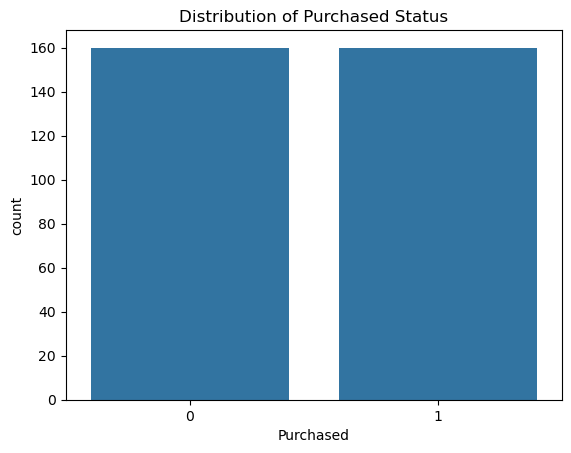

In [901]:
sns.countplot(x = y_train_smote)
plt.title('Distribution of Purchased Status')    

Scaling

In [902]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [903]:
print("Old Scale: ")
print(np.min(X_train_smote)," <-> " ,np.max(X_train_smote))

Old Scale: 
0.0  <->  87592.63


In [904]:
# only apply scaling to X values
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [905]:
print("New Scale:")
print(np.min(X_train_scaled)," <-> " ,np.max(X_train_scaled))

New Scale:
-2.2852923032304533  <->  2.5292666329253257


### Classifiers

In [906]:
from sklearn.metrics import classification_report, accuracy_score

Logistic Regression

In [907]:
from sklearn import linear_model
log_reg = linear_model.LogisticRegression()
log_reg.fit(X_train_scaled, y_train_smote)

log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_reg_pred))
print("Accuracy:", log_reg_accuracy)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.42      0.52        45
           1       0.26      0.50      0.34        18

    accuracy                           0.44        63
   macro avg       0.47      0.46      0.43        63
weighted avg       0.56      0.44      0.47        63

Accuracy: 0.4444444444444444


KNN

In [909]:
from sklearn.neighbors import KNeighborsClassifier
k = int(np.sqrt(len(y_test)))
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train_smote)
knn_pred = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)

print("K-Nearest Neighbors Classification Report:")
print(classification_report(y_test, knn_pred))
print("Accuracy:", knn_accuracy)

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.64      0.67        45
           1       0.27      0.33      0.30        18

    accuracy                           0.56        63
   macro avg       0.49      0.49      0.49        63
weighted avg       0.58      0.56      0.57        63

Accuracy: 0.5555555555555556


SVM

In [912]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train_scaled, y_train_smote)
svc_pred = svc.predict(X_test_scaled)
svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Classification Report:")
print(classification_report(y_test, svc_pred))
print("Accuracy:", svc_accuracy)

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.58      0.62        45
           1       0.21      0.28      0.24        18

    accuracy                           0.49        63
   macro avg       0.44      0.43      0.43        63
weighted avg       0.54      0.49      0.51        63

Accuracy: 0.49206349206349204


In [913]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_smote, y_train_smote)
dtc_pred = dtc.predict(X_test)

dtc_accuracy = accuracy_score(y_test, dtc_pred)
print("Decision Tree Classification Report:")
print(classification_report(y_test, dtc_pred))
print("Accuracy:", dtc_accuracy)

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.56      0.63        45
           1       0.31      0.50      0.38        18

    accuracy                           0.54        63
   macro avg       0.52      0.53      0.51        63
weighted avg       0.61      0.54      0.56        63

Accuracy: 0.5396825396825397


In [914]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_smote, y_train_smote)

rfc_pred = rfc.predict(X_test)
rfc_accuracy = accuracy_score(y_test, rfc_pred)
print("Random Forest Classification Report:")
print(classification_report(y_test, rfc_pred))
print("Accuracy:", rfc_accuracy)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.60      0.64        45
           1       0.25      0.33      0.29        18

    accuracy                           0.52        63
   macro avg       0.47      0.47      0.46        63
weighted avg       0.57      0.52      0.54        63

Accuracy: 0.5238095238095238


In [915]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)
nb_pred = nb.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Classification Report:")
print(classification_report(y_test, nb_pred))
print("Accuracy:", nb_accuracy)

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.42      0.53        45
           1       0.28      0.56      0.37        18

    accuracy                           0.46        63
   macro avg       0.49      0.49      0.45        63
weighted avg       0.58      0.46      0.48        63

Accuracy: 0.4603174603174603


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Logistic Regression'),
  Text(1, 0, 'K-Nearest Neighbors'),
  Text(2, 0, 'Support Vector Classifier'),
  Text(3, 0, 'Decision Tree'),
  Text(4, 0, 'Random Forest'),
  Text(5, 0, 'Naive Bayes')])

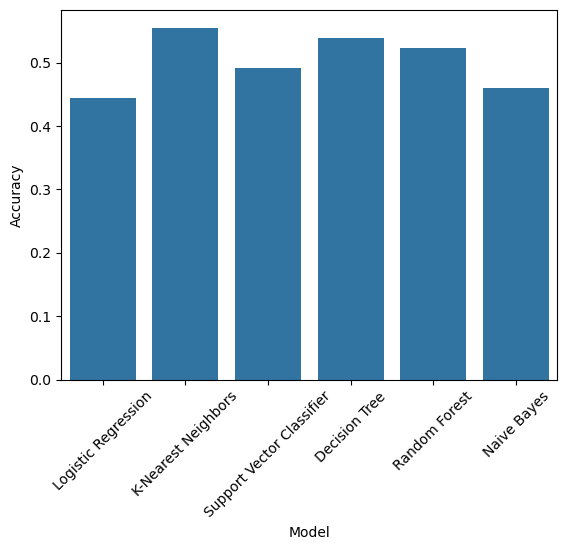

In [916]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Classifier', 'Decision Tree', 'Random Forest', 'Naive Bayes'],
    'Accuracy': [log_reg_accuracy, knn_accuracy, svc_accuracy, dtc_accuracy, rfc_accuracy, nb_accuracy]
})

sns.barplot(data=comparison, x='Model', y='Accuracy')
plt.xticks(rotation=45)
